[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/No-Country-simulation/G9-LATAM-Team-57/blob/ml-hernan/Copia_de_No_Country_simulation_G9_LATAM_Team_57.ipynb)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!wget -q https://raw.githubusercontent.com/JonathanMarino/G9-LATAM-Team-57/main/household_energy_consumption.csv -O /content/household_energy_consumption.csv
df = pd.read_csv('/content/household_energy_consumption.csv')
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [ ]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


Verificar datos faltantes

In [ ]:
df.isnull().sum()

,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,0
Avg_Temperature_C,0
Has_AC,0
Peak_Hours_Usage_kWh,0


Verificar duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

Convertir la fecha

In [ ]:
df['Date'] = df['Date'].astype(str).str.strip()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

Crear variables temporales

In [ ]:
df['Day'] = df['Date'].dt.day

df["Day_Week"] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Day_Week'].isin(['Saturday', 'Sunday'])

Verificar tipos de datos

In [ ]:
df.dtypes

,0
Household_ID,object
Date,datetime64[ns]
Energy_Consumption_kWh,float64
Household_Size,int64
Avg_Temperature_C,float64
Has_AC,object
Peak_Hours_Usage_kWh,float64
Day,int32
Day_Week,object
Is_Weekend,bool


Convertir Has_AC a variable binaria

In [ ]:
df['Has_AC'] = (df['Has_AC'].map({"Yes": 1, "No": 0}))

Crear una tarifa

In [ ]:
FEE = 0.75

df['Daily_Cost'] = (df['Energy_Consumption_kWh'] * FEE)

In [ ]:
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Day,Day_Week,Is_Weekend,Daily_Cost
0,H00001,2025-04-01,8.4,4,17.8,0,3.2,1,Tuesday,False,6.300
1,H00001,2025-04-02,7.9,4,17.3,0,2.8,2,Wednesday,False,5.925
2,H00001,2025-04-03,9.2,4,18.6,0,3.0,3,Thursday,False,6.900
3,H00001,2025-04-04,7.9,4,18.2,0,2.7,4,Friday,False,5.925
4,H00001,2025-04-05,9.6,4,11.9,0,3.2,5,Saturday,True,7.200


¿Cuántas viviendas?

In [ ]:
df['Household_ID'].nunique()

12857

¿Cuántos días analiza el dataset original?

In [ ]:
print(df['Date'].min())
print(df['Date'].max())

2025-04-01 00:00:00
2025-04-08 00:00:00


¿Cómo se distribuye el consumo energético?

---



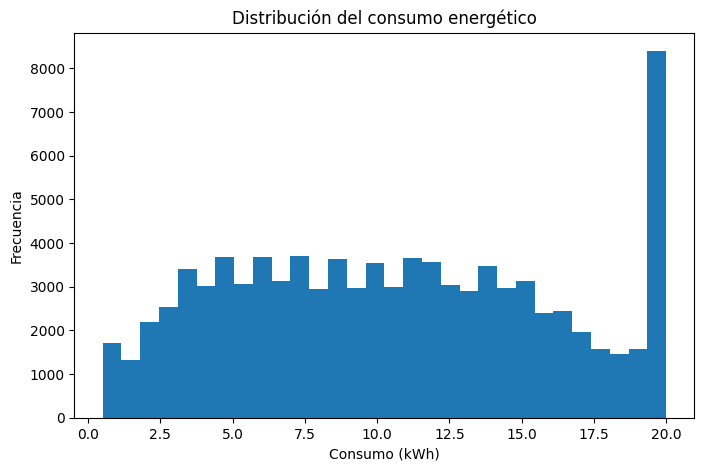

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Energy_Consumption_kWh'], bins=30)

plt.title("Distribución del consumo energético")

plt.xlabel("Consumo (kWh)")

plt.ylabel("Frecuencia")

plt.show()

¿Cuál es el consumo promedio?

In [ ]:
print(df['Energy_Consumption_kWh'].describe())

count    90000.000000
mean        10.571988
std          5.519494
min          0.500000
25%          6.000000
50%         10.400000
75%         14.800000
max         20.000000
Name: Energy_Consumption_kWh, dtype: float64


¿Qué viviendas consumen más?

In [ ]:
consumo_vivienda = (df.groupby('Household_ID')['Energy_Consumption_kWh'].mean().sort_values(ascending=False))
consumo_vivienda

,Energy_Consumption_kWh
Household_ID,
H00017,20.000000
H12807,20.000000
H12829,20.000000
H12763,20.000000
H09311,20.000000
...,...
H01271,1.228571
H10824,1.185714
H05307,1.171429


¿Qué porcentaje del consumo ocurre en horario pico?

In [ ]:
df['Porcentaje_Peak_Hour'] = (df['Peak_Hours_Usage_kWh'] /df['Energy_Consumption_kWh'])*100
df['Porcentaje_Peak_Hour'].describe()


,Porcentaje_Peak_Hour
count,90000.000000
mean,39.990695
std,5.786185
min,25.000000
25%,35.000000
50%,40.000000
75%,45.000000
max,55.555556


¿Cómo influye la temperatura?

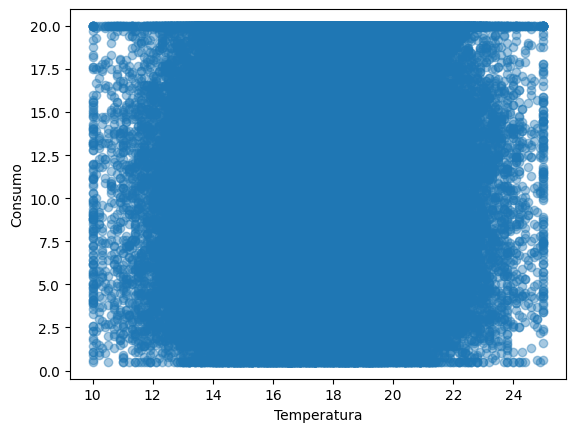

In [ ]:
plt.scatter(df['Avg_Temperature_C'],df['Energy_Consumption_kWh'],alpha=0.4)

plt.xlabel("Temperatura")

plt.ylabel("Consumo")

plt.show()

In [ ]:
df[['Avg_Temperature_C','Energy_Consumption_kWh']].corr()

,Avg_Temperature_C,Energy_Consumption_kWh
Avg_Temperature_C,1.000000,0.033315
Energy_Consumption_kWh,0.033315,1.000000


¿Las viviendas con aire consumen más?

In [ ]:
df.groupby('Has_AC')['Energy_Consumption_kWh'].mean()

,Energy_Consumption_kWh
Has_AC,
0,8.678663
1,12.508548


/tmp/ipykernel_853/1074171781.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_AC', y='Energy_Consumption_kWh', data=df, palette='Set2')


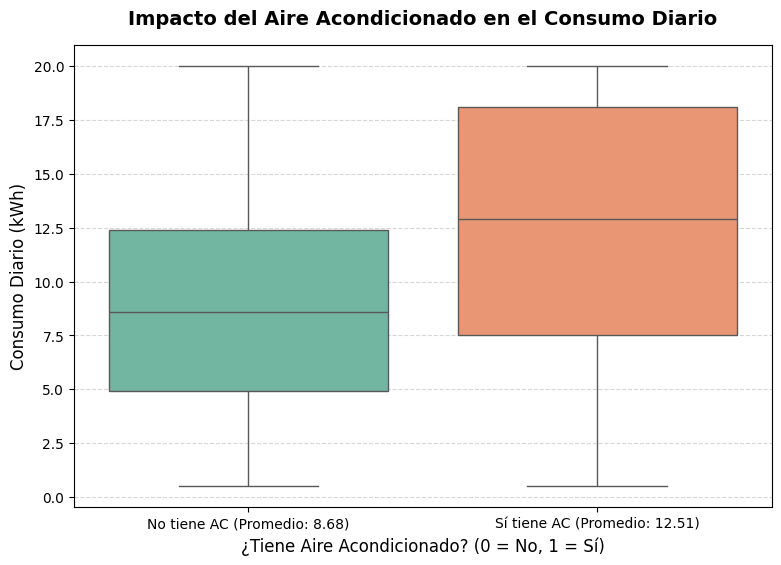

In [ ]:
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.boxplot(x='Has_AC', y='Energy_Consumption_kWh', data=df, palette='Set2')

plt.title('Impacto del Aire Acondicionado en el Consumo Diario', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('¿Tiene Aire Acondicionado? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Consumo Diario (kWh)', fontsize=12)
plt.xticks([0, 1], ['No tiene AC (Promedio: 8.68)', 'Sí tiene AC (Promedio: 12.51)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

¿Cómo influye la cantidad de personas?

In [ ]:
df.groupby('Household_Size')['Energy_Consumption_kWh'].mean()

,Energy_Consumption_kWh
Household_Size,
1,3.291343
2,6.226837
3,9.177851
4,12.249731
5,15.215470
6,17.471067


¿Cuál es el costo promedio en USD?

In [ ]:
df['Daily_Cost'].describe()

,Daily_Cost
count,90000.000000
mean,7.928991
std,4.139621
min,0.375000
25%,4.500000
50%,7.800000
75%,11.100000
max,15.000000


¿Cómo evoluciona el consumo?

<Axes: xlabel='Date'>

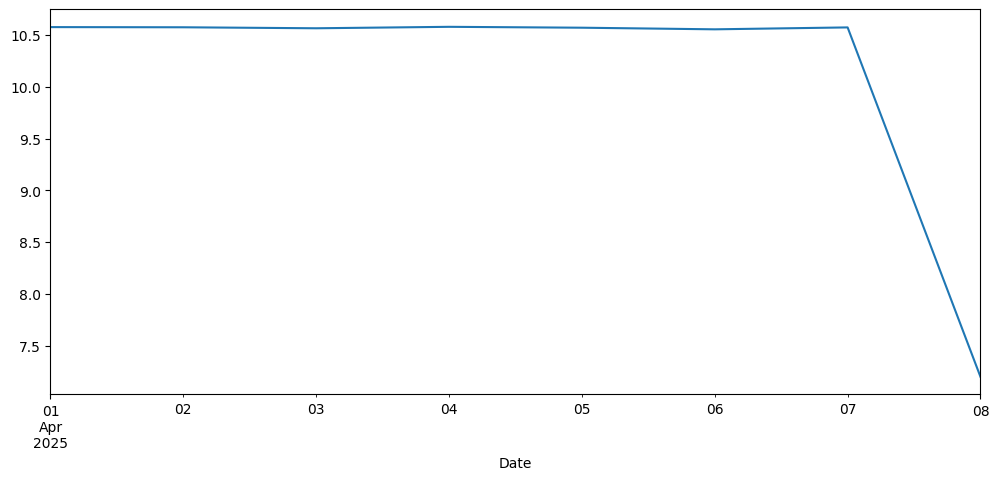

In [ ]:
consumo_diario = (
df.groupby('Date')['Energy_Consumption_kWh'].mean())

consumo_diario.plot(figsize=(12,5))

In [ ]:
consumo_dia = (df.groupby('Date')['Energy_Consumption_kWh'].agg(["mean","min","max","std"]))
consumo_dia

,mean,min,max,std
Date,,,,
2025-04-01,10.577810,0.5,20.0,5.520220
2025-04-02,10.576114,0.5,20.0,5.517483
2025-04-03,10.566547,0.5,20.0,5.516189
2025-04-04,10.580540,0.5,20.0,5.516266
2025-04-05,10.571992,0.5,20.0,5.524749
2025-04-06,10.556351,0.5,20.0,5.530616
2025-04-07,10.574823,0.5,20.0,5.512304
2025-04-08,7.200000,7.2,7.2,NaN


In [ ]:
df.groupby('Date')['Household_ID'].count()

,Household_ID
Date,
2025-04-01,12857
2025-04-02,12857
2025-04-03,12857
2025-04-04,12857
2025-04-05,12857
2025-04-06,12857
2025-04-07,12857
2025-04-08,1


In [ ]:
# Eliminamos el día 2025-04-08 por tener registros de una sola vivienda
df = df[df["Date"] != pd.Timestamp("2025-04-08")]

Correlaciones

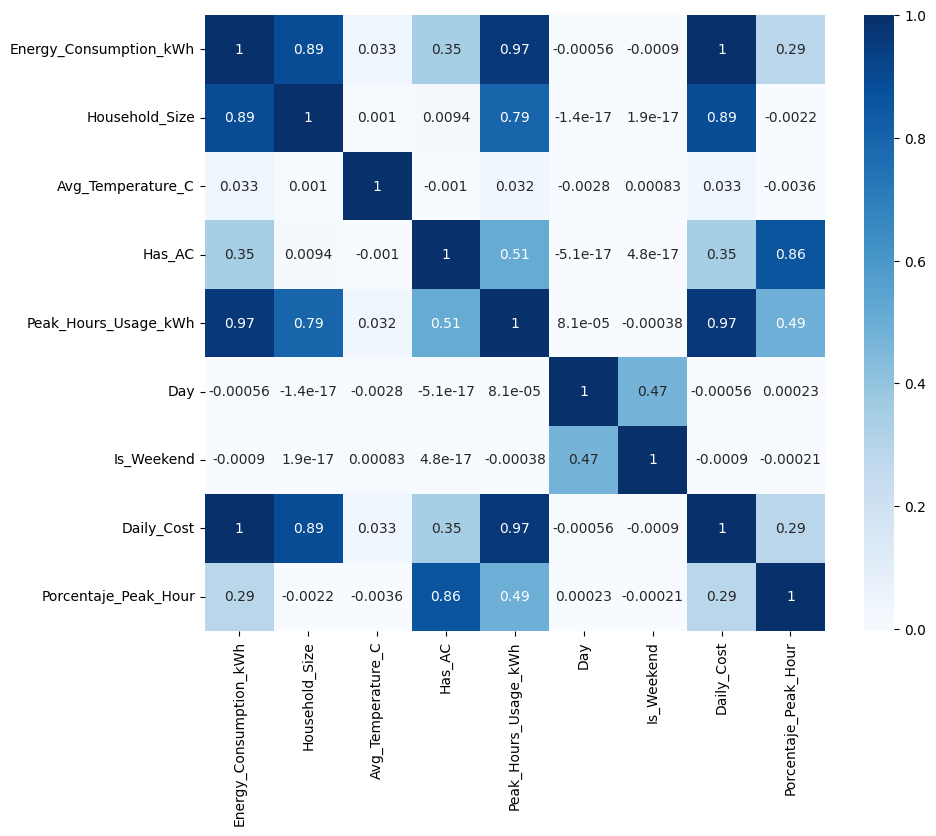

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")

plt.show()

# Tabla maestra de viviendas

In [ ]:
viviendas = (df.groupby("Household_ID").agg(cantidad_personas=("Household_Size", "first"),
                                                   tiene_aire=("Has_AC", "first"),
                                            consumo_promedio=("Energy_Consumption_kWh", "mean"),
                                              desvio_consumo=("Energy_Consumption_kWh", "std"),
                                          peak_hour_promedio=("Porcentaje_Peak_Hour", "mean")).reset_index())


viviendas.head()

,Household_ID,cantidad_personas,tiene_aire,consumo_promedio,desvio_consumo,peak_hour_promedio
0,H00001,4,0,8.514286,0.794625,35.165098
1,H00002,5,0,12.485714,1.337197,36.113464
2,H00003,3,0,7.657143,0.816205,35.122283
3,H00004,5,1,17.971429,1.312395,45.037940
4,H00005,5,0,13.242857,1.164556,33.358854


Crear variable Home_Office

In [ ]:
# Para obtener siempre el mismo resultado
np.random.seed(42)

# Estadísticas del consumo
p25 = viviendas["consumo_promedio"].quantile(0.25)
p50 = viviendas["consumo_promedio"].quantile(0.5)
p80 = viviendas["consumo_promedio"].quantile(0.80)

def asignar_homeoffice(fila):

    # Si el consumo es muy bajo, descartamos Home Office
    if fila["consumo_promedio"] < p25:
        return False

    score = 0

    # Consumo promedio (factor principal)

    if fila["consumo_promedio"] >= p80:
        score += 40
    elif fila["consumo_promedio"] >= p50:
        score += 20

    # Aire acondicionado
    if fila["tiene_aire"] == 1:
        score += 10

    # Cantidad de habitantes
    personas = fila["cantidad_personas"]

    if personas == 2:
        score += 5
    elif personas == 3:
        score += 10
    elif personas == 4:
        score += 15
    elif personas == 5:
        score += 20
    elif personas >= 6:
        score += 25

    # Convertimos el score en probabilidad

    prob = min(score / 100, 0.65)

    # Devuelve True en caso de que la probabilidad sea mayor al numero aleatorio generado
    return np.random.rand() < prob

# Crear la variable
viviendas["Home_Office"] = viviendas.apply(asignar_homeoffice,axis=1)

# Verificar distribución
print(viviendas["Home_Office"].value_counts(normalize=True))

# Cruce por cantidad de personas
print(pd.crosstab(viviendas["cantidad_personas"],viviendas["Home_Office"],normalize="index"))

Home_Office
False    0.707086
True     0.292914
Name: proportion, dtype: float64
Home_Office           False     True 
cantidad_personas                    
1                  1.000000  0.000000
2                  0.915129  0.084871
3                  0.768275  0.231725
4                  0.668391  0.331609
5                  0.474044  0.525956
6                  0.409265  0.590735


Crear variable Housing_Type

In [ ]:
np.random.seed(42)

def asignar_tipo_vivienda(fila):
    score = 0

    # Cantidad de habitantes (factor principal)

    personas = fila["cantidad_personas"]

    if personas == 1:
        score += 0
    elif personas == 2:
        score += 20
    elif personas == 3:
        score += 25
    elif personas == 4:
        score += 30
    elif personas == 5:
        score += 40
    else:
        score += 50

    # Consumo promedio

    consumo = fila["consumo_promedio"]

    if consumo >= p80:
        score += 30
    elif consumo >= p50:
        score += 20
    elif consumo >= p25:
        score += 10

    if fila["Home_Office"]:
      score += 5

    # Asignación probabilística

    if personas <= 2:

      if score >= 70:
        probabilidades = [0.80, 0.15, 0.05]

      elif score >= 50:
        probabilidades = [0.50, 0.35, 0.15]

      elif score >= 30:
        probabilidades = [0.10, 0.65, 0.25]

      else:
        probabilidades = [0.05, 0.60, 0.35]

      # Elije un tipo de vivienda aleatoriamente en funcion de la probabilidad asignada
      return np.random.choice(["Casa", "Departamento", "Monoambiente"], p=probabilidades)

    else:

    # Para hogares de 3 o más personas
      if score >= 70:
        probabilidades = [0.85, 0.15]

      elif score >= 50:
        probabilidades = [0.65, 0.35]

      else:
        probabilidades = [0.35, 0.65]

      return np.random.choice(["Casa", "Departamento"],p=probabilidades)


viviendas["Housing_Type"] = viviendas.apply(asignar_tipo_vivienda,axis=1)

# Distribución
print(viviendas["Housing_Type"].value_counts(normalize=True))

# Cruce con cantidad de personas
print(pd.crosstab(viviendas["cantidad_personas"],viviendas["Housing_Type"],normalize="index"))

Housing_Type
Casa            0.446605
Departamento    0.444738
Monoambiente    0.108657
Name: proportion, dtype: float64
Housing_Type           Casa  Departamento  Monoambiente
cantidad_personas                                      
1                  0.048624      0.595872      0.355505
2                  0.072878      0.640221      0.286900
3                  0.405638      0.594362      0.000000
4                  0.541863      0.458137      0.000000
5                  0.768670      0.231330      0.000000
6                  0.854346      0.145654      0.000000


Crear variable Equipment_Count

In [ ]:
np.random.seed(42)

def asignar_cantidad_equipos(fila):

    # -----------------------------
    # Equipos base según habitantes
    # -----------------------------
    personas = fila["cantidad_personas"]

    if personas == 1:
        equipos = 4
    elif personas == 2:
        equipos = 6
    elif personas == 3:
        equipos = 8
    elif personas == 4:
        equipos = 10
    elif personas == 5:
        equipos = 12
    else:
        equipos = 14


    # Tipo de vivienda
    if fila["Housing_Type"] == "Casa":
        equipos += 3

    elif fila["Housing_Type"] == "Departamento":
        equipos += 1

    # Home Office
    if fila["Home_Office"]:
        equipos += 2

    # Aire acondicionado
    if fila["tiene_aire"] == 1:
        equipos += 1

    # Consumo promedio
    consumo = fila["consumo_promedio"]

    if consumo >= p80:
        equipos += 2

    elif consumo >= p50:
        equipos += 1

    # Variabilidad aleatoria
    equipos += np.random.randint(-1, 2)

    # Mínimo de equipos
    equipos = max(equipos, 4)

    return int(equipos)

# Crear la variable
viviendas["Equipment_Count"] = viviendas.apply(asignar_cantidad_equipos,axis=1)

# Ver distribución
print(viviendas["Equipment_Count"].describe())

# Promedio por tipo de vivienda
print(viviendas.groupby("Housing_Type")["Equipment_Count"].mean().round(1))

# Promedio por cantidad de habitantes
print(viviendas.groupby("cantidad_personas")["Equipment_Count"].mean().round(1))

count    12857.000000
mean        12.542039
std          5.543203
min          4.000000
25%          7.000000
50%         12.000000
75%         17.000000
max         23.000000
Name: Equipment_Count, dtype: float64
Housing_Type
Casa            17.0
Departamento     9.8
Monoambiente     5.5
Name: Equipment_Count, dtype: float64
cantidad_personas
1     5.3
2     7.5
3    11.1
4    13.9
5    17.6
6    20.1
Name: Equipment_Count, dtype: float64


Crear el calendario

In [ ]:
fecha_inicio = pd.Timestamp("2025-04-08")


calendario = pd.DataFrame({"Date": pd.date_range(start=fecha_inicio,periods=60,freq="D")})

calendario["Day_Week"] = calendario["Date"].dt.dayofweek
calendario["Is_Weekend"] = calendario["Day_Week"] >= 5

calendario.head()

,Date,Day_Week,Is_Weekend
0,2025-04-08,1,False
1,2025-04-09,2,False
2,2025-04-10,3,False
3,2025-04-11,4,False
4,2025-04-12,5,True


Dimensión del calendario

In [ ]:
print(calendario.shape)

print(calendario["Date"].min())
print(calendario["Date"].max())

(60, 3)
2025-04-08 00:00:00
2025-06-06 00:00:00


Calcular la temperatura media de cada uno de los 7 días reales

In [ ]:
temperatura_diaria = (df.groupby("Date")["Avg_Temperature_C"].mean().sort_index())

temperatura_diaria


,Avg_Temperature_C
Date,
2025-04-01,17.519569
2025-04-02,17.515400
2025-04-03,17.501447
2025-04-04,17.488364
2025-04-05,17.535537
2025-04-06,17.482585
2025-04-07,17.497659


Repetir el patrón semanal

In [ ]:
patron = temperatura_diaria.values

temperaturas = []

for i in range(len(calendario)):

    temp = patron[i % 7]

    temperaturas.append(temp)

calendario["Temperatura"] = temperaturas

Agregar estacionalidad

In [ ]:
# Restamos 0.04°C por cada dia que pasa

calendario["Temperatura"] = (calendario["Temperatura"] - np.arange(len(calendario)) * 0.04)

Agregar ruido

In [ ]:
calendario["Temperatura"] += np.random.normal(loc=0, scale=0.8, size=len(calendario))

Agregar algunos eventos climáticos

In [ ]:
#Elejimos 6 dias al azar del calendario
eventos = np.random.choice(calendario.index,size=6,replace=False)

# Elije un número al azar entre -8 y 8 y se lo suma a la temperatura
for i in eventos:

    calendario.loc[i, "Temperatura"] += np.random.uniform(-8, 8)

In [ ]:
calendario["Temperatura"].describe()

,Temperatura
count,60.000000
mean,16.142229
std,1.613320
min,9.181530
25%,15.608563
50%,16.325721
75%,17.091872
max,19.117989


Cruzar cada vivienda con cada día

In [ ]:
viviendas["key"] = 1
calendario["key"] = 1

simulacion = viviendas.merge(calendario, on="key")

simulacion.drop(columns="key", inplace=True)
simulacion.shape

(771420, 13)

Simular el consumo diario

In [ ]:
np.random.seed(42)

# Crear factor de consumo

simulacion["factor_consumo"] = 1.0

# Tipo de vivienda

simulacion.loc[simulacion["Housing_Type"] == "Casa","factor_consumo"] *= 1.01

simulacion.loc[simulacion["Housing_Type"] == "Monoambiente","factor_consumo"] *= 0.99

# Home Office (solo días laborales

simulacion.loc[(simulacion["Home_Office"]) & (~simulacion["Is_Weekend"]),"factor_consumo"] *= 1.02

# Cantidad de habitantes

simulacion.loc[simulacion["cantidad_personas"] >= 5,"factor_consumo"] *= 1.02

simulacion.loc[simulacion["cantidad_personas"] == 1,"factor_consumo"] *= 0.98

# Cantidad de equipos

simulacion.loc[simulacion["Equipment_Count"] >= 18,"factor_consumo"] *= 1.02

simulacion.loc[simulacion["Equipment_Count"].between(14, 17),"factor_consumo"] *= 1.01

simulacion.loc[simulacion["Equipment_Count"] <= 8,"factor_consumo"] *= 0.98

# Aire acondicionado

simulacion.loc[simulacion["tiene_aire"] == 1,"factor_consumo"] *= 1.01

# Temperatura
# Mucho frío
simulacion.loc[simulacion["Temperatura"] < 12,"factor_consumo"] *= 1.03

# Mucho calor
simulacion.loc[simulacion["Temperatura"] > 20,"factor_consumo"] *= 1.03

# Variación aleatoria
simulacion["factor_consumo"] *= np.random.normal(1, 0.03,len(simulacion))

# 3. Simular consumo diario

simulacion["Energy_Consumption_kWh"] = np.random.normal(
    loc=simulacion["consumo_promedio"] * simulacion["factor_consumo"],
    scale=simulacion["desvio_consumo"]*0.7
)

#El piso es 0.5 KWh y el techo 20 KWh
simulacion["Energy_Consumption_kWh"] = simulacion["Energy_Consumption_kWh"].clip(lower=0.5, upper=20.0)


# 4. Simular porcentaje de hora pico

simulacion["Porcentaje_Peak_Hour"] = np.random.normal(loc=simulacion["peak_hour_promedio"],scale=2)

# Home Office aumenta ligeramente el consumo en hora pico
simulacion.loc[simulacion["Home_Office"],"Porcentaje_Peak_Hour"] += 3

#El porcentaje en hora pico no puede ser inferior al 25% ni superior al 55%
simulacion["Porcentaje_Peak_Hour"] = (simulacion["Porcentaje_Peak_Hour"].clip(25,55))

# 5. Calcular consumo en hora pico

simulacion["Peak_Hours_Usage_kWh"] = (simulacion["Energy_Consumption_kWh"] *simulacion["Porcentaje_Peak_Hour"] / 100)

# 6. Calcular costo diario

TARIFA = 0.75

simulacion["Daily_Cost"] = (simulacion["Energy_Consumption_kWh"] * TARIFA)

simulacion.head()

,Household_ID,cantidad_personas,tiene_aire,consumo_promedio,desvio_consumo,peak_hour_promedio,Home_Office,Housing_Type,Equipment_Count,Date,Day_Week,Is_Weekend,Temperatura,factor_consumo,Energy_Consumption_kWh,Porcentaje_Peak_Hour,Peak_Hours_Usage_kWh,Daily_Cost
0,H00001,4,0,8.514286,0.794625,35.165098,False,Departamento,12,2025-04-08,1,False,17.698211,1.014901,8.846374,36.064408,3.190393,6.634781
1,H00001,4,0,8.514286,0.794625,35.165098,False,Departamento,12,2025-04-09,2,False,18.262186,0.995852,8.607280,33.498683,2.883325,6.455460
2,H00001,4,0,8.514286,0.794625,35.165098,False,Departamento,12,2025-04-10,3,False,18.248735,1.019431,8.056538,33.984968,2.738012,6.042404
3,H00001,4,0,8.514286,0.794625,35.165098,False,Departamento,12,2025-04-11,4,False,12.993252,1.045691,7.915505,36.294592,2.872900,5.936629
4,H00001,4,0,8.514286,0.794625,35.165098,False,Departamento,12,2025-04-12,5,True,16.524342,0.992975,8.614008,35.677645,3.073275,6.460506


In [ ]:
simulacion.groupby("Date")["Temperatura"].first()

,Temperatura
Date,
2025-04-08,17.698211
2025-04-09,18.262186
2025-04-10,18.248735
2025-04-11,12.993252
2025-04-12,16.524342
2025-04-13,18.611460
2025-04-14,18.387563
2025-04-15,17.290401
2025-04-16,16.089984


In [ ]:
simulacion.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771420 entries, 0 to 771419
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Household_ID            771420 non-null  object        
 1   cantidad_personas       771420 non-null  int64         
 2   tiene_aire              771420 non-null  int64         
 3   consumo_promedio        771420 non-null  float64       
 4   desvio_consumo          771420 non-null  float64       
 5   peak_hour_promedio      771420 non-null  float64       
 6   Home_Office             771420 non-null  bool          
 7   Housing_Type            771420 non-null  object        
 8   Equipment_Count         771420 non-null  int64         
 9   Date                    771420 non-null  datetime64[ns]
 10  Day_Week                771420 non-null  int32         
 11  Is_Weekend              771420 non-null  bool          
 12  Temperatura             771420

In [ ]:
print(df.columns.tolist())

print(simulacion.columns.tolist())

['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'Day', 'Day_Week', 'Is_Weekend', 'Daily_Cost', 'Porcentaje_Peak_Hour']
['Household_ID', 'cantidad_personas', 'tiene_aire', 'consumo_promedio', 'desvio_consumo', 'peak_hour_promedio', 'Home_Office', 'Housing_Type', 'Equipment_Count', 'Date', 'Day_Week', 'Is_Weekend', 'Temperatura', 'factor_consumo', 'Energy_Consumption_kWh', 'Porcentaje_Peak_Hour', 'Peak_Hours_Usage_kWh', 'Daily_Cost']


Renombrar columnas de simulacion

In [ ]:
simulacion = simulacion.rename(columns={
    "cantidad_personas": "Household_Size",
    "tiene_aire": "Has_AC",
    "Temperatura": "Avg_Temperature_C"
})

Agregar Year, Month y Day a la simulación

In [ ]:
simulacion["Day"] = simulacion["Date"].dt.day

Agregar las variables sintéticas al df

In [ ]:
columnas = [
    "Household_ID",
    "Home_Office",
    "Housing_Type",
    "Equipment_Count"
]

df = df.merge(
    viviendas[columnas],
    on="Household_ID",
    how="left"
)

Eliminamos variables auxiliares

In [ ]:
simulacion.drop(columns=["factor_consumo", "consumo_promedio", "desvio_consumo", "peak_hour_promedio"],inplace=True)

Reordenar columnas

In [ ]:
simulacion = simulacion[df.columns]

Concatenamos dataset real y simulado

In [ ]:
df_final = pd.concat([df, simulacion],ignore_index=True)

df_final = df_final.sort_values(["Household_ID", "Date"]).reset_index(drop=True)

df_final.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Day,Day_Week,Is_Weekend,Daily_Cost,Porcentaje_Peak_Hour,Home_Office,Housing_Type,Equipment_Count
0,H00001,2025-04-01,8.4,4,17.8,0,3.2,1,Tuesday,False,6.300,38.095238,False,Departamento,12
1,H00001,2025-04-02,7.9,4,17.3,0,2.8,2,Wednesday,False,5.925,35.443038,False,Departamento,12
2,H00001,2025-04-03,9.2,4,18.6,0,3.0,3,Thursday,False,6.900,32.608696,False,Departamento,12
3,H00001,2025-04-04,7.9,4,18.2,0,2.7,4,Friday,False,5.925,34.177215,False,Departamento,12
4,H00001,2025-04-05,9.6,4,11.9,0,3.2,5,Saturday,True,7.200,33.333333,False,Departamento,12


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861419 entries, 0 to 861418
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Household_ID            861419 non-null  object        
 1   Date                    861419 non-null  datetime64[ns]
 2   Energy_Consumption_kWh  861419 non-null  float64       
 3   Household_Size          861419 non-null  int64         
 4   Avg_Temperature_C       861419 non-null  float64       
 5   Has_AC                  861419 non-null  int64         
 6   Peak_Hours_Usage_kWh    861419 non-null  float64       
 7   Day                     861419 non-null  int32         
 8   Day_Week                861419 non-null  object        
 9   Is_Weekend              861419 non-null  bool          
 10  Daily_Cost              861419 non-null  float64       
 11  Porcentaje_Peak_Hour    861419 non-null  float64       
 12  Home_Office             861419

Análisis Exploratorio de Datos (EDA)

Distribución del consumo diario

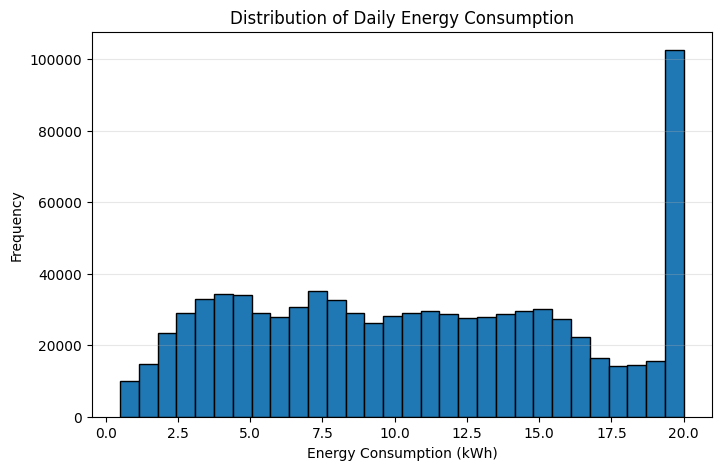

count    861419.000000
mean         10.801217
std           5.711855
min           0.500000
25%           5.888113
50%          10.542506
75%          15.395198
max          20.000000
Name: Energy_Consumption_kWh, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df_final["Energy_Consumption_kWh"],bins=30,edgecolor="black")

plt.title("Distribution of Daily Energy Consumption")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Estadísticas descriptivas
print(df_final["Energy_Consumption_kWh"].describe())

Evolución del consumo diario

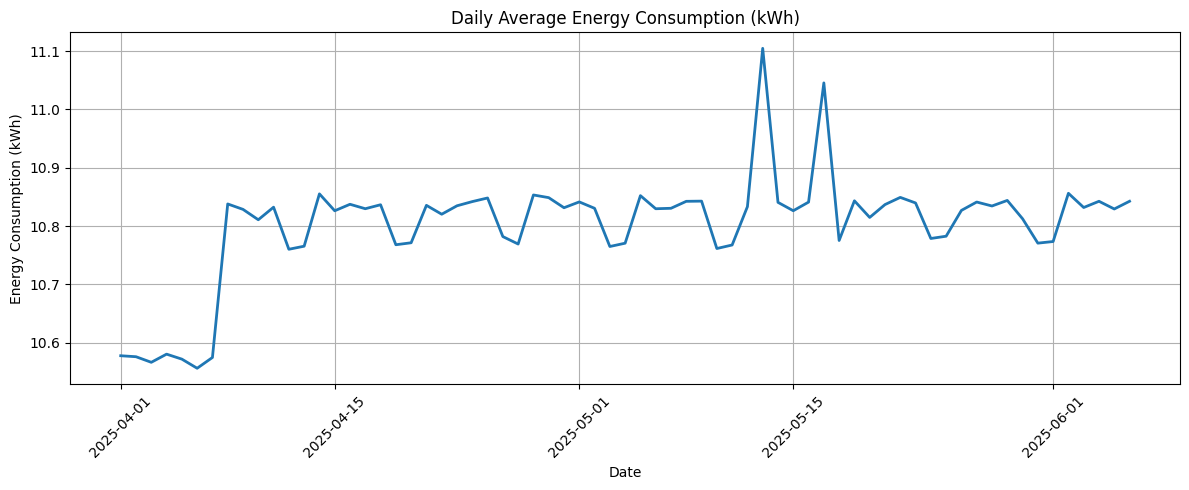

In [ ]:
cons_diario = df_final.groupby("Date", as_index=False)["Energy_Consumption_kWh"].mean()

# Gráfico
plt.figure(figsize=(12,5))

plt.plot(
    cons_diario["Date"],
    cons_diario["Energy_Consumption_kWh"],
    linewidth=2
)

plt.title("Daily Average Energy Consumption (kWh)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Evolución de la Temperatura

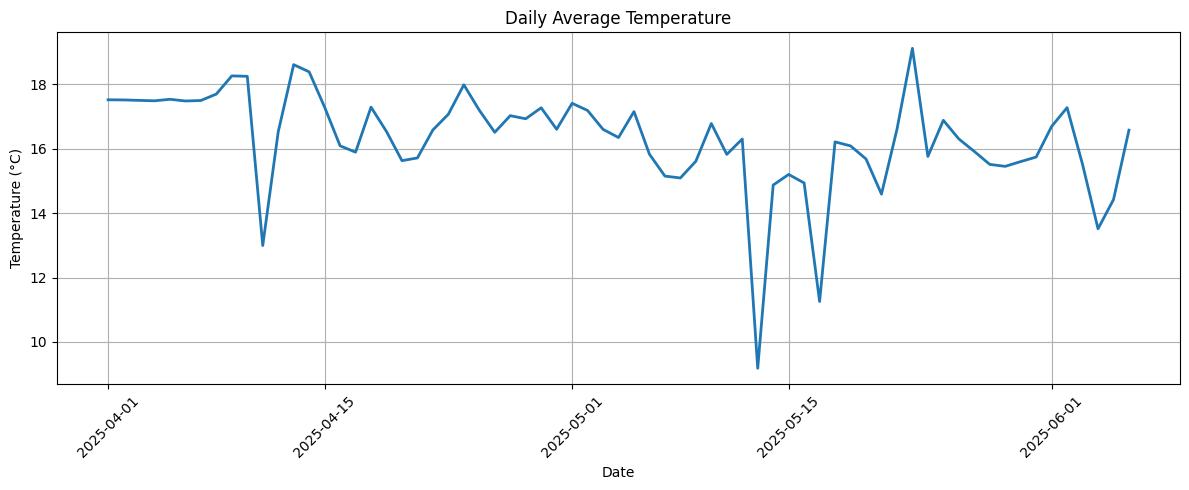

In [ ]:
temp_diaria = df_final.groupby("Date", as_index=False)["Avg_Temperature_C"].mean()

# Gráfico
plt.figure(figsize=(12,5))

plt.plot(
    temp_diaria["Date"],
    temp_diaria["Avg_Temperature_C"],
    linewidth=2
)

plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Consumo según tipo de vivienda

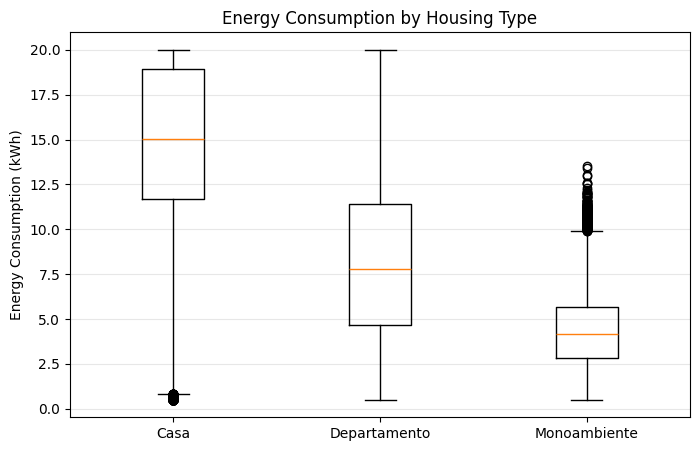

In [ ]:
tipos = ["Casa", "Departamento", "Monoambiente"]

datos = [df_final.loc[df_final["Housing_Type"] == tipo,"Energy_Consumption_kWh"] for tipo in tipos]

plt.figure(figsize=(8,5))

plt.boxplot(datos,tick_labels=tipos)

plt.title("Energy Consumption by Housing Type")
plt.ylabel("Energy Consumption (kWh)")

plt.grid(axis="y", alpha=0.3)

plt.show()

Consumo según cantidad de habitantes

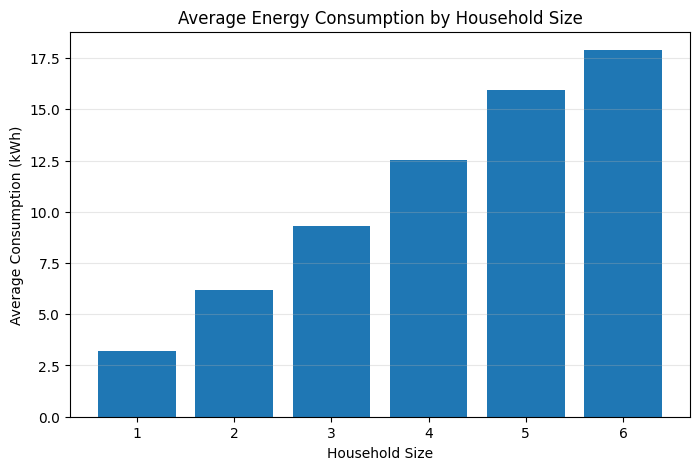

In [ ]:
consumo = df_final.groupby("Household_Size")["Energy_Consumption_kWh"].mean()

plt.figure(figsize=(8,5))

plt.bar(consumo.index.astype(str), consumo.values)

plt.title("Average Energy Consumption by Household Size")
plt.xlabel("Household Size")
plt.ylabel("Average Consumption (kWh)")

plt.grid(axis="y", alpha=0.3)

plt.show()

Matriz de correlación

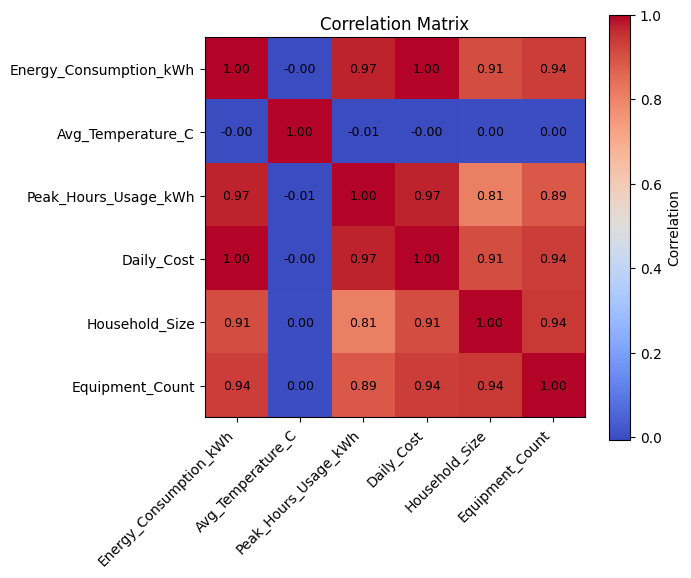

In [ ]:
corr = df_final[["Energy_Consumption_kWh", "Avg_Temperature_C", "Peak_Hours_Usage_kWh","Daily_Cost", "Household_Size", "Equipment_Count"]].corr()

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap='coolwarm')

plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha="right")

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar(label="Correlation")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=9)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

Consumo promedio por día de la semana

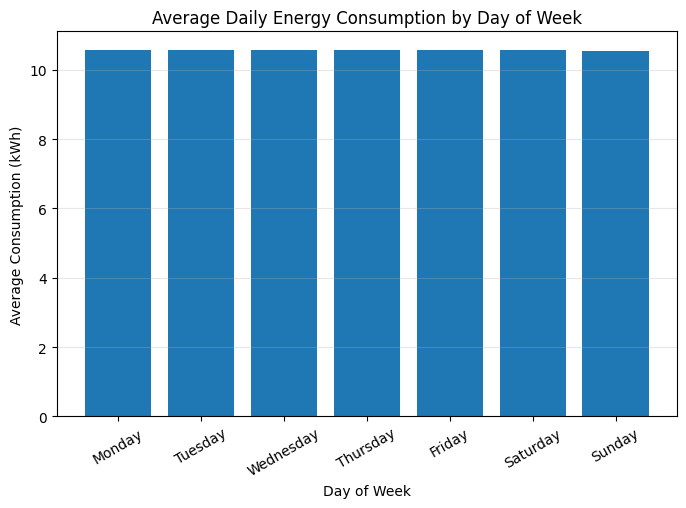

In [ ]:
orden = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

consumo = (df_final.groupby("Day_Week")["Energy_Consumption_kWh"].mean().reindex(orden))

plt.figure(figsize=(8,5))

plt.bar(consumo.index,consumo.values)

plt.title("Average Daily Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Consumption (kWh)")

plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.show()

Tabla Maestra Viviendas Final

In [ ]:
viviendas_final = (df_final.groupby("Household_ID").agg(Household_Size=("Household_Size", "first"),
                                                        Has_AC=("Has_AC", "first"),
                                                        Home_Office=("Home_Office", "first"),
                                                        Housing_Type=("Housing_Type", "first"),
                                                        Equipment_Count=("Equipment_Count", "first"),
                                                        Avg_Energy_Consumption_kWh=("Energy_Consumption_kWh", "mean"),
                                                        Std_Energy_Consumption_kWh=("Energy_Consumption_kWh", "std"),
                                                        Avg_Peak_Hours_Usage_kWh=("Peak_Hours_Usage_kWh", "mean"),
                                                        Avg_Peak_Hour_Percentage=("Porcentaje_Peak_Hour", "mean"),
                                                        Avg_Daily_Cost=("Daily_Cost", "mean"),
                                                        Avg_Temperature_C=("Avg_Temperature_C", "mean")).reset_index())

viviendas_final.head()

,Household_ID,Household_Size,Has_AC,Home_Office,Housing_Type,Equipment_Count,Avg_Energy_Consumption_kWh,Std_Energy_Consumption_kWh,Avg_Peak_Hours_Usage_kWh,Avg_Peak_Hour_Percentage,Avg_Daily_Cost,Avg_Temperature_C
0,H00001,4,0,False,Departamento,12,8.367209,0.631039,2.919958,34.920659,6.275407,16.204981
1,H00002,5,0,False,Departamento,13,12.636666,0.996668,4.603042,36.430124,9.477499,16.363190
2,H00003,3,0,False,Departamento,10,7.654631,0.642341,2.679429,34.992927,5.740974,16.213936
3,H00004,5,1,True,Casa,21,19.123040,0.933025,9.053436,47.327503,14.342280,16.225876
4,H00005,5,0,True,Casa,17,13.917835,0.960537,5.024042,36.094988,10.438377,16.336324


Crear variable Perfil Energetico

In [ ]:
# ENERGY PROFILE

# 1. Consumo por habitante
viviendas_final["Consumption_per_Person"] = (viviendas_final["Avg_Energy_Consumption_kWh"] /
                                             viviendas_final["Household_Size"])
# 2. Energy Score
# Ordena los consumos y los transforma en porcentaje
Consumption_Rank = viviendas_final["Consumption_per_Person"].rank(pct=True)

Peak_Rank = viviendas_final["Avg_Peak_Hour_Percentage"].rank(pct=True)

viviendas_final['Energy_Score'] = (Consumption_Rank + Peak_Rank) / 2

# 3. Definir umbrales (terciles)

q1 = viviendas_final["Energy_Score"].quantile(0.33)
q2 = viviendas_final["Energy_Score"].quantile(0.66)

# 4. Crear perfil energético
# Evalua cada score y le asigna un tipo de perfil
viviendas_final["Energy_Profile"] = np.where(viviendas_final["Energy_Score"] <= q1,"Efficient",
    np.where(viviendas_final["Energy_Score"] <= q2, "Moderate", "Inefficient"))

# 5. Distribución de perfiles

print(viviendas_final["Energy_Profile"].value_counts())


print(viviendas_final["Energy_Profile"].value_counts(normalize=True) * 100)

# 6. Unimos con el dataset con registros diarios

df_final = df_final.merge( viviendas_final[["Household_ID", "Energy_Profile"]],on="Household_ID",how="left")

Energy_Profile
Inefficient    4372
Efficient      4244
Moderate       4241
Name: count, dtype: int64
Energy_Profile
Inefficient    34.004822
Efficient      33.009256
Moderate       32.985922
Name: proportion, dtype: float64


In [ ]:
viviendas_final.drop(columns=["Energy_Score"],inplace=True)

Promedio de los indicadores utilizados para la clasificación del perfil energético

In [ ]:
viviendas_final.groupby("Energy_Profile")[["Consumption_per_Person","Avg_Peak_Hour_Percentage"]].mean()

,Consumption_per_Person,Avg_Peak_Hour_Percentage
Energy_Profile,,
Efficient,2.416790,34.936527
Inefficient,3.831485,46.667993
Moderate,3.070247,40.557043


Distribución del consumo de energía por persona según el perfil energético

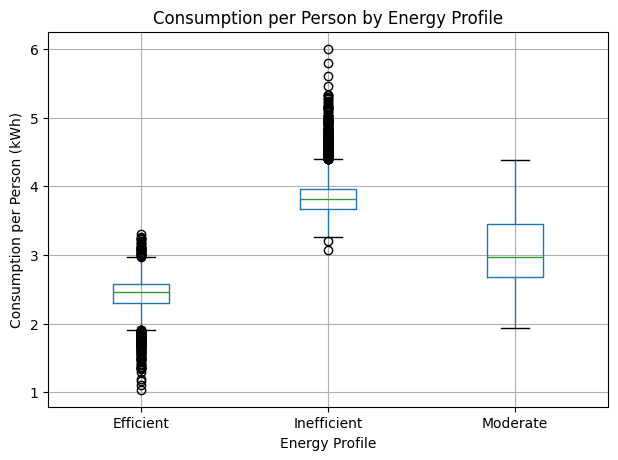

In [ ]:
viviendas_final.boxplot(column="Consumption_per_Person",by="Energy_Profile",figsize=(7,5))

plt.title("Consumption per Person by Energy Profile")
plt.suptitle("")
plt.xlabel("Energy Profile")
plt.ylabel("Consumption per Person (kWh)")
plt.show()


Distribución del consumo en hora pico según perfil energético

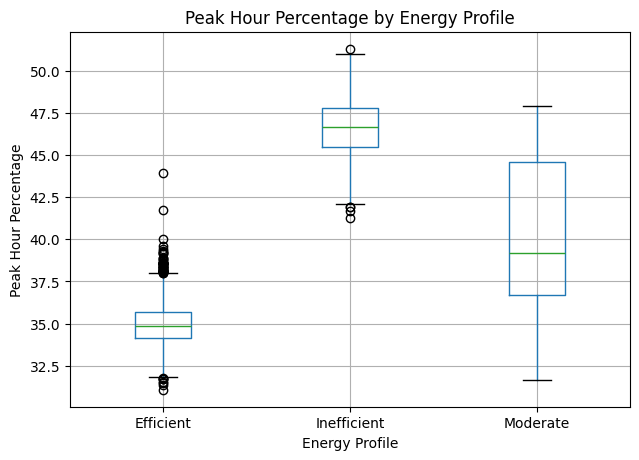

In [ ]:
viviendas_final.boxplot(column="Avg_Peak_Hour_Percentage",by="Energy_Profile",figsize=(7,5))

plt.title("Peak Hour Percentage by Energy Profile")
plt.suptitle("")
plt.xlabel("Energy Profile")
plt.ylabel("Peak Hour Percentage")
plt.show()


Consumo diario promedio de energía y tamaño del hogar según el perfil energético

In [ ]:
tabla_consumo = viviendas_final.groupby("Energy_Profile")[["Avg_Energy_Consumption_kWh", "Household_Size"]].mean().rename(columns={
        "Avg_Energy_Consumption_kWh": "Average Daily Energy Consumption (kWh)",
        "Household_Size": "Average Household Size"
    })


tabla_consumo

,Average Daily Energy Consumption (kWh),Average Household Size
Energy_Profile,,
Efficient,7.754751,3.141847
Inefficient,13.126146,3.522187
Moderate,11.453094,3.798632


Clasificación del nivel de consumo en hora pico

In [ ]:
p35 = viviendas_final["Avg_Peak_Hours_Usage_kWh"].quantile(0.35)
p65 = viviendas_final["Avg_Peak_Hours_Usage_kWh"].quantile(0.65)

viviendas_final["Peak_Usage_Level"] = np.where(
    viviendas_final["Avg_Peak_Hours_Usage_kWh"] <= p35,
    "Low",
    np.where(
        viviendas_final["Avg_Peak_Hours_Usage_kWh"] <= p65,
        "Medium",
        "High"
    )
)

# Ver distribución
print(viviendas_final["Peak_Usage_Level"].value_counts())
print(viviendas_final["Peak_Usage_Level"].value_counts(normalize=True) * 100)

viviendas_final.groupby("Peak_Usage_Level")["Avg_Peak_Hours_Usage_kWh"].describe()[["min", "mean", "max"]]


Peak_Usage_Level
Low       4500
High      4500
Medium    3857
Name: count, dtype: int64
Peak_Usage_Level
Low       35.000389
High      35.000389
Medium    29.999222
Name: proportion, dtype: float64


,min,mean,max
Peak_Usage_Level,,,
High,5.312843,7.630552,10.134583
Low,0.387015,1.771517,3.055751
Medium,3.056740,4.150795,5.312815


Preparación de Features (X) y Target (y) para Machine Learning

In [ ]:
# Seleccionamos las variables de entrada (features), evitando usar las mismas
# variables con las que se construyó el Energy_Profile (Consumption_per_Person
# y Avg_Peak_Hour_Percentage), para que el modelo aprenda un patrón real
# y no memorice la fórmula del score (data leakage).

features = [
    "Household_Size", "Has_AC", "Home_Office", "Housing_Type",
    "Equipment_Count", "Avg_Energy_Consumption_kWh",
    "Peak_Usage_Level"]
X = viviendas_final[features].copy()
X["Home_Office"] = X["Home_Office"].astype(int)

y = viviendas_final["Energy_Profile"].copy()

División en conjuntos de Entrenamiento y Prueba (Train/Test Split)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train: (10285, 7) Test: (2572, 7)
Energy_Profile
Inefficient    0.340010
Efficient      0.330092
Moderate       0.329898
Name: proportion, dtype: float64


Preprocesador

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Housing_Type",
    "Peak_Usage_Level"
]

numeric_features = [
    "Household_Size",
    "Has_AC",
    "Home_Office",
    "Equipment_Count",
    "Avg_Energy_Consumption_kWh"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

Evaluación de Modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Regresión Logística
log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# Árbol de Decisión
tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
tree.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Housing_Type',
                                                   'Peak_Usage_Level'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

Evaluación de Modelos

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

modelos = {
    "Regresión Logística": log_reg,
    "Random Forest": rf,
    "Árbol de Decisión": tree
}

resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    resultados.append({"Modelo": nombre, "Accuracy": acc, "F1_macro": f1})
    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred))

pd.DataFrame(resultados).sort_values("F1_macro", ascending=False)


=== Regresión Logística ===
              precision    recall  f1-score   support

   Efficient       0.86      0.92      0.89       849
 Inefficient       0.86      0.94      0.90       875
    Moderate       0.83      0.70      0.76       848

    accuracy                           0.85      2572
   macro avg       0.85      0.85      0.85      2572
weighted avg       0.85      0.85      0.85      2572


=== Random Forest ===
              precision    recall  f1-score   support

   Efficient       0.86      0.88      0.87       849
 Inefficient       0.86      0.88      0.87       875
    Moderate       0.75      0.72      0.73       848

    accuracy                           0.83      2572
   macro avg       0.82      0.83      0.83      2572
weighted avg       0.83      0.83      0.83      2572


=== Árbol de Decisión ===
              precision    recall  f1-score   support

   Efficient       0.87      0.87      0.87       849
 Inefficient       0.86      0.88      0.87       

,Modelo,Accuracy,F1_macro
0,Regresión Logística,0.852644,0.848556
1,Random Forest,0.826594,0.825189
2,Árbol de Decisión,0.824650,0.823454


Prueba Nuevo Usuario

In [ ]:
nuevo_usuario = pd.DataFrame({
    "Household_Size":[6],
    "Has_AC":[1],
    "Home_Office":[0],
    "Housing_Type":["Casa"],
    "Equipment_Count":[20],
    "Avg_Energy_Consumption_kWh":[1],
    "Peak_Usage_Level":["Low"]
})

pred = rf.predict(nuevo_usuario)
pred

array(['Moderate'], dtype=object)

Matriz de confusión

<Figure size 500x400 with 0 Axes>

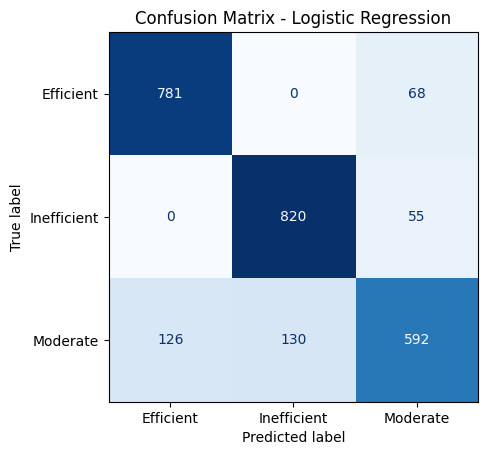

<Figure size 500x400 with 0 Axes>

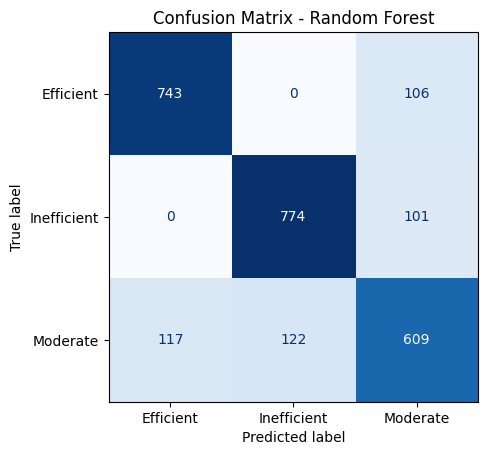

<Figure size 500x400 with 0 Axes>

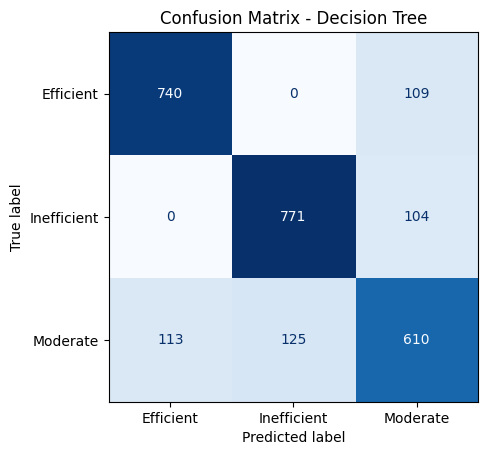

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

modelos = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Decision Tree": tree
}

for nombre, modelo in modelos.items():

    plt.figure(figsize=(5,4))

    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_test,
        y_test,
        cmap="Blues",
        colorbar=False
    )

    plt.title(f"Confusion Matrix - {nombre}")
    plt.show()


Importancia de variables (Random Forest)

In [ ]:
feature_names = rf.named_steps["preprocessor"].get_feature_names_out()

importancias = rf.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importancias
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
8,remainder__Avg_Energy_Consumption_kWh,0.442060
5,remainder__Has_AC,0.277391
6,remainder__Home_Office,0.107414
4,remainder__Household_Size,0.074010
7,remainder__Equipment_Count,0.050722
2,cat__Peak_Usage_Level_Low,0.026843
3,cat__Peak_Usage_Level_Medium,0.016015
0,cat__Housing_Type_Departamento,0.004346
1,cat__Housing_Type_Monoambiente,0.001199


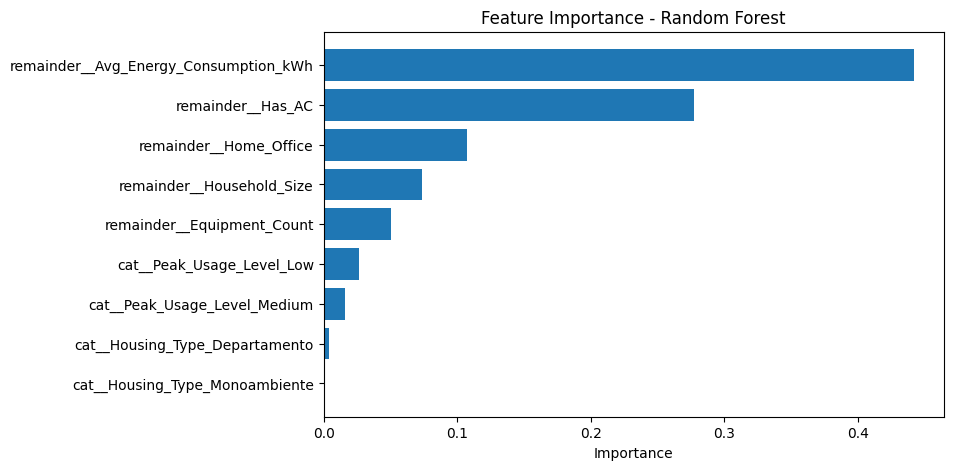

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")

plt.show()

Guardar el modelo

In [ ]:
import joblib

joblib.dump(log_reg, "energy_profile_model.pkl")

['energy_profile_model.pkl']

In [ ]:
modelo = joblib.load("energy_profile_model.pkl")

In [ ]:
nuevo = pd.DataFrame({
    "Household_Size":[4],
    "Has_AC":[1],
    "Home_Office":[0],
    "Equipment_Count":[8],
    "Avg_Energy_Consumption_kWh":[12],
    "Peak_Usage_Level":["Medium"],
    'Housing_Type' : ["Casa"]
})

In [ ]:
pred = modelo.predict(nuevo)
pred

array(['Moderate'], dtype=object)